<a href="https://colab.research.google.com/github/JihaeChun/RL_202512_20team/blob/main/%EA%B0%95%ED%99%94%ED%95%99%EC%8A%B5_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_2%EB%94%94%ED%81%90%EC%97%942.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#프로젝트 data 불러오기!
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path1 = '/content/drive/MyDrive/Colab Notebooks/data1.csv'
file_path2 = '/content/drive/MyDrive/Colab Notebooks/data2.csv'
data1=pd.read_csv(file_path1)
data2=pd.read_csv(file_path2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data1

,KEY,번호,성별,연령대,결혼여부,자녀운전여부,차종코드,이전유입채널,신규갱신,갱신연차,만기일자,갱신여부,계약dday
0,20245685608,006271788,남자,50대,1,N,2U01,광고,갱신,5차년,2025-10-22,Y,32
1,20245692470,006278016,남자,70대,1,N,2V01,광고,신규,1차년,2025-10-22,Y,43
2,20245704110,006555989,남자,50대,1,N,2V01,직접유입,갱신,3차년,2025-10-22,Y,12
3,20245733494,006272844,남자,40대,1,N,2U01,광고,갱신,5차년,2025-10-22,Y,24
4,20245742851,006557268,남자,50대,1,N,2U01,직접유입,갱신,2차년,2025-10-22,Y,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3508,20248064688,006589094,남자,20대,1,N,2Q01,직접유입,신규,1차년,2025-10-22,Y,1
3509,20248067447,006585275,남자,40대,1,N,2G01,직접유입,신규,1차년,2025-10-22,Y,8
3510,20248108143,006109677,남자,60대,1,N,2G01,직접유입,신규,1차년,2025-10-22,Y,1
3511,20248177864,006008799,남자,20대,1,N,3A01,광고,신규,1차년,2025-10-22,Y,10


In [ ]:
data2

,KEY,번호,캠페인번호,캠페인명,만기까지남은일수,클릭여부
0,20245685608,006271788,C0000019,경품_야간갱신,37,N
1,20245685608,006271788,E0000002,ED-40 (계약사항 및 만기 안내 ),40,N
2,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,33,N
3,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,40,N
4,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,41,N
...,...,...,...,...,...,...
43364,20248067447,006585275,C0000008,마일리지환급금안내(ED-16),16,N
43365,20248067447,006585275,E0000001,ED-60(보험료절감방법),60,N
43366,20248067447,006585275,E0000002,ED-40 (계약사항 및 만기 안내 ),40,N
43367,20248178406,005030122,B0000006,ED-1,1,N


In [ ]:
#train/test 데이터 나누기
from sklearn.model_selection import train_test_split
cust_train_df, cust_test_df = train_test_split(data1,test_size=0.3, random_state=42, shuffle=True)

In [ ]:
cust_train_df

,KEY,번호,성별,연령대,결혼여부,자녀운전여부,차종코드,이전유입채널,신규갱신,갱신연차,만기일자,갱신여부,계약dday
2985,20246615488,006589401,남자,30대,1,N,2Q01,광고,신규,1차년,2025-10-22,Y,0
2067,20246571598,006274278,남자,40대,1,N,20,직접유입,갱신,2차년,2025-10-22,N,0
801,20246281496,006578366,남자,50대,1,N,2W01,직접유입,갱신,2차년,2025-10-22,Y,36
2119,20246573223,006588561,여자,30대,1,N,2R01,광고,갱신,4차년,2025-10-22,Y,2
2216,20246576196,006588932,남자,50대,1,N,2U01,광고,갱신,2차년,2025-10-22,Y,-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,20246408751,006558467,남자,40대,1,N,2U01,직접유입,갱신,5차년,2025-10-22,Y,27
1294,20246425600,005757657,남자,50대,1,N,2S01,광고,갱신,5차년,2025-10-22,Y,34
860,20246311806,006294664,여자,50대,1,N,2Q01,광고,갱신,4차년,2025-10-22,Y,30
3507,20247989870,005799645,여자,50대,1,N,2U01,직접유입,신규,1차년,2025-10-22,N,0


In [ ]:
cust_test_df

,KEY,번호,성별,연령대,결혼여부,자녀운전여부,차종코드,이전유입채널,신규갱신,갱신연차,만기일자,갱신여부,계약dday
527,20246193527,006570711,남자,30대,1,N,3A01,직접유입,갱신,5차년,2025-10-22,Y,29
691,20246260404,006576855,남자,60대,1,Y,2S01,직접유입,갱신,5차년,2025-10-22,Y,19
511,20246185128,006574455,남자,50대,1,N,2U01,직접유입,갱신,5차년,2025-10-22,Y,8
1228,20246416725,005145782,남자,70대,1,N,2S01,직접유입,갱신,5차년,2025-10-22,Y,3
1624,20246495970,006298733,남자,40대,1,N,2S01,직접유입,갱신,5차년,2025-10-22,Y,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,20246612614,006481323,남자,60대,1,N,2Q01,제휴,신규,5차년,2025-10-22,Y,0
1270,20246418845,006298583,남자,60대,1,N,2S01,광고,신규,1차년,2025-10-22,Y,9
2350,20246579003,006572640,남자,30대,1,N,2Q01,직접유입,갱신,4차년,2025-10-22,Y,6
944,20246338647,006274849,남자,40대,1,N,2S01,직접유입,갱신,2차년,2025-10-22,Y,11


In [ ]:
cust_train_df_id = set(cust_train_df['KEY'])
cust_test_df_id  = set(cust_test_df['KEY'])

lms_train_df = data2[data2['KEY'].isin(cust_train_df_id)].copy()
lms_test_df  = data2[data2['KEY'].isin(cust_test_df_id)].copy()

In [ ]:
lms_train_df

,KEY,번호,캠페인번호,캠페인명,만기까지남은일수,클릭여부
6,20245692470,006278016,E0000001,ED-60(보험료절감방법),60,N
7,20245704110,006555989,B0000003,ED-16,15,N
8,20245733494,006272844,C0000007,마일리지환급금안내(ED-25),25,N
9,20245733494,006272844,C0000019,경품_야간갱신,26,N
10,20245733494,006272844,C0000019,경품_야간갱신,37,N
...,...,...,...,...,...,...
43364,20248067447,006585275,C0000008,마일리지환급금안내(ED-16),16,N
43365,20248067447,006585275,E0000001,ED-60(보험료절감방법),60,N
43366,20248067447,006585275,E0000002,ED-40 (계약사항 및 만기 안내 ),40,N
43367,20248178406,005030122,B0000006,ED-1,1,N


In [ ]:
lms_test_df

,KEY,번호,캠페인번호,캠페인명,만기까지남은일수,클릭여부
0,20245685608,006271788,C0000019,경품_야간갱신,37,N
1,20245685608,006271788,E0000002,ED-40 (계약사항 및 만기 안내 ),40,N
2,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,33,N
3,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,40,N
4,20245685608,006271788,P0000006,자동차만기갱신 카드이벤트,41,N
...,...,...,...,...,...,...
43260,20247181534,006029865,C0000007,마일리지환급금안내(ED-25),25,N
43261,20247181534,006029865,C0000008,마일리지환급금안내(ED-16),16,N
43263,20247287631,005559302,C0000007,마일리지환급금안내(ED-25),25,N
43298,20247716378,006284378,B0000006,ED-1,1,N


# 1. 데이터 전처리

In [ ]:
# 1단계: 고객 + 발송데이터 merge (KEY기준)
# - 보상은 고객 데이터의 '갱신여부' 사용

cust_cols_for_merge = [
    'KEY', '성별', '연령대', '결혼여부', '자녀운전여부',
    '차종코드', '이전유입채널', '신규갱신', '갱신연차', '갱신여부'
]

train_merged = pd.merge(
    lms_train_df,
    cust_train_df[cust_cols_for_merge],
    on='KEY',
    how='left'
)

test_merged = pd.merge(
    lms_test_df,
    cust_test_df[cust_cols_for_merge],
    on='KEY',
    how='left'
)

print("Train merge shape:", train_merged.shape)
print(train_merged.head())

print("Test merge shape:", test_merged.shape)
print(test_merged.head())

########################################################
# Y/N → 숫자 변환 함수
########################################################
def yn_to_num(x):
    if isinstance(x, str):
        x = x.strip().upper()
        if x == 'Y': return 1.0
        if x == 'N': return 0.0
    # 결측 또는 기타 값은 0
    return 0.0

########################################################
# 🔥 갱신여부 / 클릭여부 모두 변환
########################################################
train_merged['갱신여부_num']  = train_merged['갱신여부'].apply(yn_to_num)
test_merged['갱신여부_num']   = test_merged['갱신여부'].apply(yn_to_num)

# 👉 여기가 추가 포인트
train_merged['클릭여부_num']  = train_merged['클릭여부'].apply(yn_to_num)
test_merged['클릭여부_num']   = test_merged['클릭여부'].apply(yn_to_num)

########################################################
# 변환 샘플 출력
########################################################
print("=== Y/N → 숫자 변환 샘플(train) ===")
display(train_merged[['갱신여부','갱신여부_num','클릭여부','클릭여부_num']].head(10))

print("\n=== 갱신여부_num 분포 (train) ===")
print(train_merged['갱신여부_num'].value_counts(dropna=False))

print("\n=== 클릭여부_num 분포 (train) ===")
print(train_merged['클릭여부_num'].value_counts(dropna=False))

Train merge shape: (31031, 15)
           KEY         번호     캠페인번호              캠페인명  만기까지남은일수 클릭여부  성별  연령대  \
0  20245692470  006278016  E0000001    ED-60(보험료절감방법)        60    N  남자  70대   
1  20245704110  006555989  B0000003             ED-16        15    N  남자  50대   
2  20245733494  006272844  C0000007  마일리지환급금안내(ED-25)        25    N  남자  40대   
3  20245733494  006272844  C0000019           경품_야간갱신        26    N  남자  40대   
4  20245733494  006272844  C0000019           경품_야간갱신        37    N  남자  40대   

   결혼여부 자녀운전여부  차종코드 이전유입채널 신규갱신 갱신연차 갱신여부  
0     1      N  2V01     광고   신규  1차년    Y  
1     1      N  2V01   직접유입   갱신  3차년    Y  
2     1      N  2U01     광고   갱신  5차년    Y  
3     1      N  2U01     광고   갱신  5차년    Y  
4     1      N  2U01     광고   갱신  5차년    Y  
Test merge shape: (12338, 15)
           KEY         번호     캠페인번호                   캠페인명  만기까지남은일수 클릭여부  성별  \
0  20245685608  006271788  C0000019                경품_야간갱신        37    N  남자   
1  20245685608  0062

,갱신여부,갱신여부_num,클릭여부,클릭여부_num
0,Y,1.0,N,0.0
1,Y,1.0,N,0.0
2,Y,1.0,N,0.0
3,Y,1.0,N,0.0
4,Y,1.0,N,0.0
5,Y,1.0,N,0.0
6,Y,1.0,N,0.0
7,Y,1.0,N,0.0
8,Y,1.0,N,0.0
9,Y,1.0,N,0.0



=== 갱신여부_num 분포 (train) ===
갱신여부_num
1.0    24911
0.0     6120
Name: count, dtype: int64

=== 클릭여부_num 분포 (train) ===
클릭여부_num
0.0    29707
1.0     1324
Name: count, dtype: int64


In [ ]:
#2단계: 데이터전처리
state_cols = [
    '성별', '연령대', '결혼여부', '자녀운전여부',
    '차종코드', '이전유입채널', '갱신연차', '만기까지남은일수'
]
action_col = '캠페인번호'
reward_col = '갱신여부_num'



for c in state_cols + [action_col]:
    if train_merged[c].isnull().any():
        train_merged[c] = train_merged[c].fillna('UNKNOWN')
    if test_merged[c].isnull().any():
        test_merged[c] = test_merged[c].fillna('UNKNOWN')

# ================================
# 8. 범주형 → 정수 ID 인코딩
#    - train 기준으로 encoder 만들고
#    - train/test 모두 *_id 컬럼으로 변환
# ================================
encoders = {}

for c in state_cols + [action_col]:
    train_vals = train_merged[c].astype(str)
    test_vals  = test_merged[c].astype(str)

    cats = sorted(train_vals.unique())
    encoder = {v: i for i, v in enumerate(cats)}
    encoders[c] = encoder

    train_merged[c + '_id'] = train_vals.map(encoder)

    # test는 train에 없는 값이 있을 수 있으니 -1로
    test_merged[c + '_id'] = test_vals.map(lambda v: encoder.get(v, -1))

print("인코딩된 train_merged 예시:")
display(train_merged.head())

인코딩된 train_merged 예시:


,KEY,번호,캠페인번호,캠페인명,만기까지남은일수,클릭여부,성별,연령대,결혼여부,자녀운전여부,...,클릭여부_num,성별_id,연령대_id,결혼여부_id,자녀운전여부_id,차종코드_id,이전유입채널_id,갱신연차_id,만기까지남은일수_id,캠페인번호_id
0,20245692470,006278016,E0000001,ED-60(보험료절감방법),60,N,남자,70대,1,N,...,0.0,0,5,0,0,8,1,0,24,10
1,20245704110,006555989,B0000003,ED-16,15,N,남자,50대,1,N,...,0.0,0,3,0,0,8,4,2,5,0
2,20245733494,006272844,C0000007,마일리지환급금안내(ED-25),25,N,남자,40대,1,N,...,0.0,0,2,0,0,7,1,4,11,5
3,20245733494,006272844,C0000019,경품_야간갱신,26,N,남자,40대,1,N,...,0.0,0,2,0,0,7,1,4,12,9
4,20245733494,006272844,C0000019,경품_야간갱신,37,N,남자,40대,1,N,...,0.0,0,2,0,0,7,1,4,18,9


# 2. DQN
~~~

# 1️⃣: 라이브러리 로드 및 환경 설정

In [ ]:
# 0) 라이브러리 로드
import numpy as np
import pandas as pd
import random, math, time
from collections import defaultdict, deque
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange, tqdm

# Optional: LightGBM for probability models
try:
    import lightgbm as lgb
    LGB_PRESENT = True
except Exception as e:
    LGB_PRESENT = False
    print("LightGBM not found. Will fallback to frequency-based probabilities.")

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cpu


# 2️⃣: 하이퍼파라미터 / 보상 정의

In [ ]:
# 1) 하이퍼파라미터 및 보상 상수
CLICK_REWARD = 3.5
RENEWAL_REWARD = 10.0
SEND_PENALTY = -0.1

GAMMA = 0.98
LR = 5e-4
BATCH_SIZE = 128
REPLAY_CAPACITY = 200000
NUM_EPISODES = 4000
TARGET_UPDATE_STEPS = 1000
EPS_START = 0.8
EPS_END = 0.05
EPS_DECAY = 0.9995

# 3️⃣: 데이터 컬럼 정의 / 상태 벡터 생성

In [ ]:
# 2) 기본 컬럼 정의
days_col = '만기까지남은일수'
key_col = 'KEY'

static_state_id_cols = [
    '성별_id','연령대_id','결혼여부_id','자녀운전여부_id',
    '차종코드_id','이전유입채널_id','갱신연차_id'
]

ACTION_SPACE = [0, 1]  # 0=NOT_SEND, 1=SEND
N_ACTIONS = len(ACTION_SPACE)

# state builder
def build_state_vector(row, send_count, last_click, last_campaign_idx):
    days_left = float(row[days_col]) if not pd.isna(row[days_col]) else 0.0
    send_bucket = float(min(send_count,5))
    last_click_f = float(last_click)
    last_campaign_f = float(last_campaign_idx if last_campaign_idx is not None else -1)
    static_feats = []
    for c in static_state_id_cols:
        v = row.get(c,0)
        try:
            static_feats.append(float(int(v)))
        except:
            static_feats.append(0.0)
    return np.array([days_left, send_bucket, last_click_f, last_campaign_f]+static_feats, dtype=np.float32)

# determine STATE_DIM
sample_row = train_merged.iloc[0]
STATE_DIM = build_state_vector(sample_row,0,0,-1).shape[0]
print("STATE_DIM:", STATE_DIM)


STATE_DIM: 11


# 4️⃣: Simulator 구축 (Click / Renew Probabilities)

In [ ]:
# ==========================================
# 📌 1. Simulator 학습용 데이터 생성
# ==========================================
sim_rows = []

for sid, group in train_merged.groupby('KEY'):
    group = group.sort_values(days_col, ascending=False)  # 높은 days_left 먼저
    send_count = 0
    last_gap = 99
    last_campaign_idx = -1

    for i in range(len(group)):
        row = group.iloc[i]

        # 상태 벡터 생성
        state_vec = build_state_vector(row, send_count, last_gap, last_campaign_idx)

        # Action index
        action_idx = int(row[action_col + '_id'])

        # Simulator 학습용 타겟
        click = int(row['클릭여부_num'])          # 실 click 여부
        renew = int(row['갱신여부_num'])      # episode 최종 갱신 여부

        sim_rows.append({
            'state': state_vec,
            'action': action_idx,
            'click': click,
            'renew': renew
        })

        # episode 내부 counter 업데이트
        send_count += 1
        if i < len(group) - 1:
            next_row = group.iloc[i + 1]
            last_gap = abs(int(row[days_col]) - int(next_row[days_col]))
        else:
            last_gap = 99

        last_campaign_idx = action_idx

print("Simulator rows:", len(sim_rows))

Simulator rows: 31031


In [ ]:
# ==========================================
# 📌 2. Simulator (LightGBM) 입력 데이터 생성
# ==========================================

X = []
y_click = []
y_renew = []

for r in sim_rows:
    feat = np.concatenate([r['state'], [r['action']]])
    X.append(feat)
    y_click.append(r['click'])
    y_renew.append(r['renew'])

X = np.array(X, dtype=np.float32)
y_click = np.array(y_click, dtype=np.int8)
y_renew = np.array(y_renew, dtype=np.int8)

print("X:", X.shape)
print("y_click:", y_click.shape)
print("y_renew:", y_renew.shape)


X: (31031, 12)
y_click: (31031,)
y_renew: (31031,)


In [ ]:
# 3) Simulator: click / renew probability models
# X,y_click,y_renew 준비 완료되어 있어야 함 (이전 Notebook 블록 참고)
if LGB_PRESENT:
    print("Training LightGBM models for click and renew...")
    dtrain_click = lgb.Dataset(X, label=y_click)
    params = {'objective':'binary','metric':'binary_logloss','verbosity':-1,'seed':42}
    click_model = lgb.train(params,dtrain_click,num_boost_round=100)
    dtrain_renew = lgb.Dataset(X,label=y_renew)
    renew_model = lgb.train(params,dtrain_renew,num_boost_round=100)

    def predict_probs_models(state_vec,action):
        feat = np.array(list(state_vec)+[action]).reshape(1,-1)
        pc = float(click_model.predict(feat)[0])
        pr = float(renew_model.predict(feat)[0])
        return max(0.0,min(1.0,pc)), max(0.0,min(1.0,pr))
else:
    print("Using frequency-based probability tables")
    freq_send = defaultdict(lambda: defaultdict(int))
    freq_click = defaultdict(lambda: defaultdict(int))
    freq_renew = defaultdict(lambda: defaultdict(int))
    for idx,r in model_df.iterrows():
        d = 'd0_7' if r['days_left']<=7 else ('d8_30' if r['days_left']<=30 else 'd31p')
        age = str(r['age'])
        sb = str(min(int(r['send_count']),5))
        k = (d, age, sb)
        a = int(r['action'])
        freq_send[k][a] += 1
        freq_click[k][a] += int(r['click'])
        freq_renew[k][a] += int(r['renew'])
    global_click_rate = sum(sum(v.values()) for v in freq_click.values()) / max(1,sum(sum(v.values()) for v in freq_send.values()))
    global_renew_rate = sum(sum(v.values()) for v in freq_renew.values()) / max(1,sum(sum(v.values()) for v in freq_send.values()))

    def predict_probs_models(state_vec,action):
        days_left = int(state_vec[0])
        d = 'd0_7' if days_left<=7 else ('d8_30' if days_left<=30 else 'd31p')
        idx_age_in_vec = 4+static_state_id_cols.index('연령대_id') if '연령대_id' in static_state_id_cols else 5
        try: age_id = int(state_vec[idx_age_in_vec])
        except: age_id=-1
        age=str(age_id)
        sb=str(int(state_vec[1]))
        k=(d,age,sb)
        tot=freq_send.get(k,{}).get(action,0)
        clicks=freq_click.get(k,{}).get(action,0)
        rens=freq_renew.get(k,{}).get(action,0)
        if tot==0: return global_click_rate,global_renew_rate
        pc=(clicks+1)/(tot+2)
        pr=(rens+1)/(tot+2)
        return pc,pr

# 샘플 테스트
sv = build_state_vector(sample_row,0,0,-1)
print("Sample P(click,renew) for action=1:", predict_probs_models(sv,1))


Training LightGBM models for click and renew...
Sample P(click,renew) for action=1: (0.0006816073365601626, 0.8477105951426526)


# 5️⃣: Gym-like 환경 정의

In [ ]:
# 4) RL Insurance Env
class RLInsuranceEnv:
    def __init__(self, df, predict_probs_fn, click_reward=CLICK_REWARD, renewal_reward=RENEWAL_REWARD, send_penalty=SEND_PENALTY, stochastic=True):
        self.df = df
        self.predict_probs = predict_probs_fn
        self.click_reward = click_reward
        self.renewal_reward = renewal_reward
        self.send_penalty = send_penalty
        self.stochastic = stochastic
        self.episodes = list(df[key_col].unique())
        self.idx = 0

    def reset(self):
        if self.idx >= len(self.episodes):
            self.idx = 0
            random.shuffle(self.episodes)
        key = self.episodes[self.idx]; self.idx+=1
        group=self.df[self.df[key_col]==key].sort_values(days_col,ascending=False).reset_index(drop=True)
        self.group = group
        self.step_idx=0; self.send_count=0; self.last_click=0; self.last_camp=-1; self.done=False
        row=self.group.iloc[0]
        return build_state_vector(row,self.send_count,self.last_click,self.last_camp)

    def step(self,action):
        if self.done: raise RuntimeError("Episode done. Call reset()")
        row=self.group.iloc[self.step_idx]
        state_vec=build_state_vector(row,self.send_count,self.last_click,self.last_camp)
        pc,pr=self.predict_probs(state_vec,action)
        if self.stochastic:
            clicked=(random.random()<pc) if action==1 else False
            renewed=(random.random()<pr) if (action==1 and self.step_idx==len(self.group)-1) else False
        else:
            clicked=(pc>=0.5) and action==1
            renewed=(pr>=0.5) and action==1 and self.step_idx==len(self.group)-1
        reward=0.0
        if action==1: reward+=self.send_penalty; reward+=self.click_reward if clicked else 0
        if self.step_idx==len(self.group)-1 and renewed: reward+=self.renewal_reward
        # next state
        if self.step_idx<len(self.group)-1:
            next_row=self.group.iloc[self.step_idx+1]
            next_state=build_state_vector(next_row,self.send_count+(1 if action==1 else 0),int(abs(int(row[days_col])-int(next_row[days_col]))),self.last_camp)
            done=False
        else:
            next_state=np.zeros(STATE_DIM,dtype=np.float32)
            done=True
        # update counters
        if action==1: self.send_count+=1; self.last_click=int(clicked)
        self.step_idx+=1
        self.done=done
        return next_state,reward,done,{'clicked':clicked,'renewed':renewed,'pc':pc,'pr':pr}


# 6️⃣: DQN 정의 및 ReplayBuffer

In [ ]:
# 5) DQN agent
class SimpleDQN(nn.Module):
    def __init__(self,input_dim,n_actions,hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,hidden),nn.ReLU(),
            nn.Linear(hidden,hidden//2),nn.ReLU(),
            nn.Linear(hidden//2,n_actions)
        )
    def forward(self,x): return self.net(x)

class ReplayBuffer:
    def __init__(self,capacity=REPLAY_CAPACITY):
        self.buf=deque(maxlen=capacity)
    def push(self,s,a,r,sn,d): self.buf.append((s,a,r,sn,d))
    def sample(self,batch_size):
        batch=random.sample(self.buf,min(batch_size,len(self.buf)))
        s,a,r,sn,d=zip(*batch)
        return np.array(s),np.array(a),np.array(r),np.array(sn),np.array(d)
    def __len__(self): return len(self.buf)

policy_net=SimpleDQN(STATE_DIM,N_ACTIONS).to(DEVICE)
target_net=SimpleDQN(STATE_DIM,N_ACTIONS).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
optimizer=optim.Adam(policy_net.parameters(),lr=LR)
mse_loss=nn.MSELoss()
replay=ReplayBuffer(REPLAY_CAPACITY)


# 7️⃣: Online DQN Training

In [ ]:
# 6) Online training
env = RLInsuranceEnv(train_merged,predict_probs_models,stochastic=True)
step_count=0
eps=EPS_START
episode_rewards=[]

for ep in trange(NUM_EPISODES,desc="DQN training"):
    s=env.reset()
    ep_reward=0.0
    for t in range(200):
        # epsilon-greedy
        a=random.choice(ACTION_SPACE) if random.random()<eps else int(torch.argmax(policy_net(torch.tensor(s,dtype=torch.float32).to(DEVICE).unsqueeze(0))).item())
        s2,r,done,info=env.step(a)
        replay.push(s,a,r,s2,done)
        ep_reward+=r
        s=s2
        # train step
        if len(replay)>=BATCH_SIZE:
            sb,ab,rb,snb,db=replay.sample(BATCH_SIZE)
            sb_t=torch.tensor(sb,dtype=torch.float32).to(DEVICE)
            ab_t=torch.tensor(ab,dtype=torch.long).to(DEVICE)
            rb_t=torch.tensor(rb,dtype=torch.float32).unsqueeze(1).to(DEVICE)
            snb_t=torch.tensor(snb,dtype=torch.float32).to(DEVICE)
            db_t=torch.tensor(db,dtype=torch.float32).unsqueeze(1).to(DEVICE)
            q_all=policy_net(sb_t)
            q_sa=q_all.gather(1,ab_t.unsqueeze(1))
            with torch.no_grad():
                q_next=target_net(snb_t)
                q_next_max=q_next.max(dim=1)[0].unsqueeze(1)
                q_target=rb_t+GAMMA*q_next_max*(1.0-db_t)
            loss=mse_loss(q_sa,q_target)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        step_count+=1
        if step_count%TARGET_UPDATE_STEPS==0:
            target_net.load_state_dict(policy_net.state_dict())
        if done: break
    episode_rewards.append(ep_reward)
    eps=max(EPS_END,eps*EPS_DECAY)
    if ep%100==0:
        print(f"[EP {ep}] recent_mean_reward={np.mean(episode_rewards[-100:]) if len(episode_rewards)>=1 else 0:.4f}, eps={eps:.4f}")


DQN training:   0%|          | 9/4000 [00:00<00:49, 80.46it/s]

[EP 0] recent_mean_reward=0.0000, eps=0.7996


DQN training:   3%|▎         | 106/4000 [00:06<03:26, 18.89it/s]

[EP 100] recent_mean_reward=3.8660, eps=0.7606


DQN training:   5%|▌         | 204/4000 [00:13<02:43, 23.24it/s]

...

DQN training:  95%|█████████▌| 3802/4000 [05:38<00:15, 13.07it/s]

[EP 3800] recent_mean_reward=6.7980, eps=0.1195


DQN training:  98%|█████████▊| 3903/4000 [05:49<00:11,  8.67it/s]

[EP 3900] recent_mean_reward=6.9170, eps=0.1137


DQN training: 100%|██████████| 4000/4000 [06:00<00:00, 11.11it/s]


# 8️⃣: Policy Rollout / Evaluation

In [ ]:
# 7) Evaluation
def rollout_policy_on_df(df,policy_net,predict_probs_fn,mode='greedy'):
    policy_net.eval()
    rewards,renewals,send_counts=[],[],[]
    for sid,group in df.groupby(key_col):
        group=group.sort_values(days_col,ascending=False).reset_index(drop=True)
        send_count,last_click,last_camp=0,0,-1
        s=build_state_vector(group.iloc[0],send_count,last_click,last_camp)
        ep_r,renewed_flag,sends=0.0,0,0
        for i,row in group.iterrows():
            if mode=='greedy':
                with torch.no_grad():
                    qv=policy_net(torch.tensor(s,dtype=torch.float32).to(DEVICE).unsqueeze(0))
                    a=int(torch.argmax(qv,dim=1).item())
            else: a=random.choice(ACTION_SPACE)
            pc,pr=predict_probs_fn(s,a)
            clicked=(random.random()<pc) if a==1 else False
            renewed=(random.random()<pr) if (a==1 and i==len(group)-1) else False
            if a==1: ep_r+=SEND_PENALTY; sends+=1; ep_r+=CLICK_REWARD if clicked else 0
            if renewed: ep_r+=RENEWAL_REWARD; renewed_flag=1
            if i<len(group)-1:
                next_row=group.iloc[i+1]
                s=build_state_vector(next_row,send_count+(1 if a==1 else 0),int(abs(int(row[days_col])-int(next_row[days_col]))),last_camp)
            else: s=np.zeros(STATE_DIM,dtype=np.float32)
            send_count+=(1 if a==1 else 0)
        rewards.append(ep_r)
        renewals.append(renewed_flag)
        send_counts.append(sends)
    return np.array(rewards),np.array(renewals),np.array(send_counts)

# rollout
test_rewards,test_renewals,test_sends = rollout_policy_on_df(test_merged,policy_net,predict_probs_models,mode='greedy')
print("Test mean reward:", np.mean(test_rewards))
print("Test renewal rate:", np.mean(test_renewals))
print("Avg sends/customer:", np.mean(test_sends))


Test mean reward: 7.096748878923767
Test renewal rate: 0.6266816143497758
Avg sends/customer: 7.4742152466367715


# 9️⃣: Baseline & Uplift

In [ ]:
baseline_renew_by_key = test_merged.groupby(key_col).agg({'갱신여부_num':'max'}).reset_index()
baseline_renew_rate = baseline_renew_by_key['갱신여부_num'].mean()
print("Baseline renewal rate:", baseline_renew_rate)
print("Renewal uplift:", np.mean(test_renewals)-baseline_renew_rate)
print("Mean reward uplift:", np.mean(test_rewards)-(SEND_PENALTY*test_merged.groupby(key_col).size().mean()))


Baseline renewal rate: 0.8295964125560538
Renewal uplift: -0.202914798206278
Mean reward uplift: 8.47993273542601


# 🔟: Save Policy

In [ ]:
torch.save(policy_net.state_dict(),'/content/dqn_policy_send_not_send.pth')
print("Saved policy to /content/dqn_policy_send_not_send.pth")

Saved policy to /content/dqn_policy_send_not_send.pth


# 1) 학습곡선: Episode reward (원시 + 이동평균)

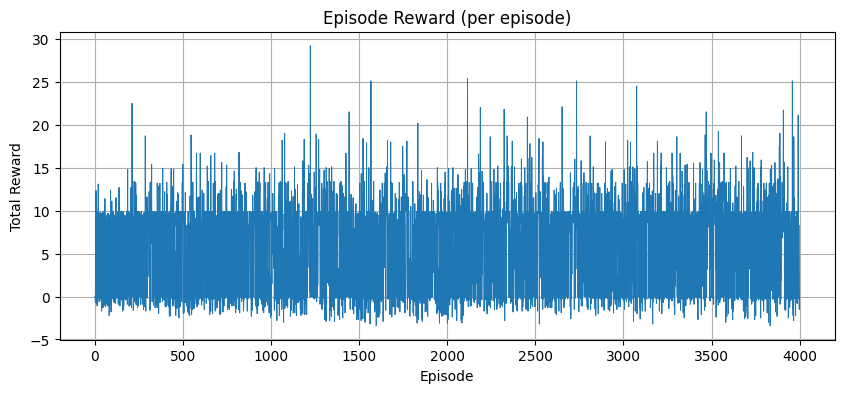

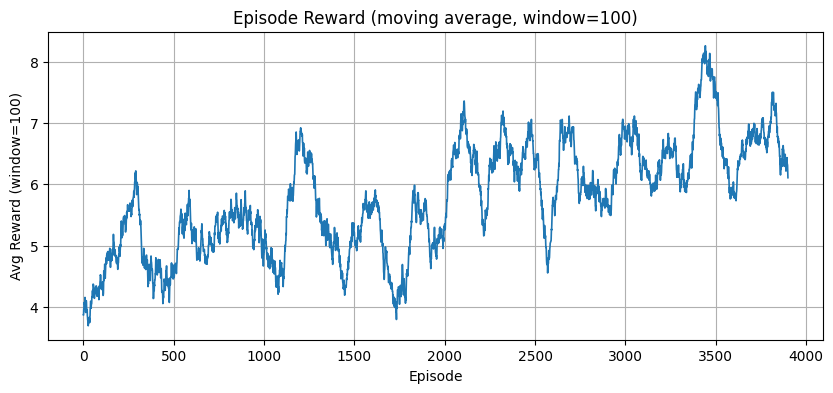

In [ ]:
# Plot 1: episode rewards (raw + moving average)
import matplotlib.pyplot as plt
import numpy as np

# episode_rewards : list or np.array of per-episode total reward recorded during training
er = np.array(episode_rewards)  # 이미 존재한다고 가정

# moving average (window)
def moving_average(x, w=100):
    if len(x) < w:
        return np.convolve(x, np.ones(len(x))/len(x), mode='valid')
    return np.convolve(x, np.ones(w)/w, mode='valid')

ma = moving_average(er, w=100)

plt.figure(figsize=(10,4))
plt.plot(er, linewidth=0.7)
plt.title("Episode Reward (per episode)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ma, linewidth=1.2)
plt.title("Episode Reward (moving average, window=100)")
plt.xlabel("Episode")
plt.ylabel("Avg Reward (window=100)")
plt.grid(True)
plt.show()

# Test set rollout 결과 시각화: Reward 분포, Renewal distribution, Sends 분포

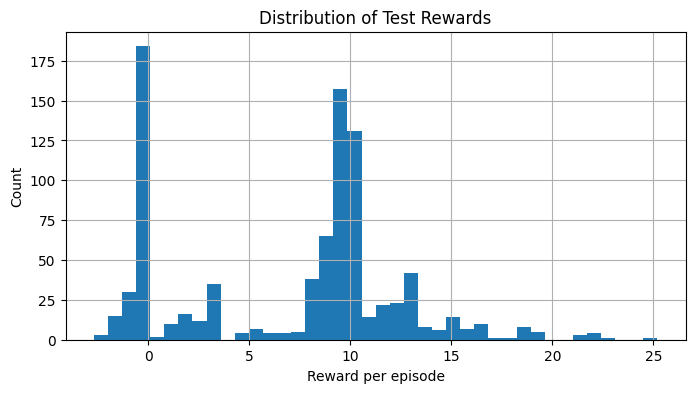

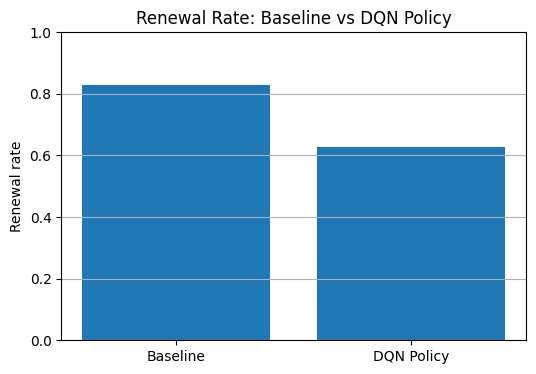

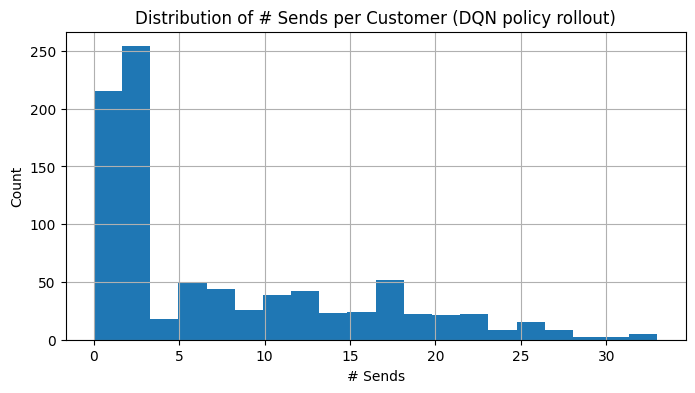

In [ ]:
# rollout_policy_on_df로 이미 얻은 결과들 사용
# test_rewards, test_renewals, test_sends (numpy arrays)

import matplotlib.pyplot as plt
import numpy as np

# Reward histogram
plt.figure(figsize=(8,4))
plt.hist(test_rewards, bins=40)
plt.title("Distribution of Test Rewards")
plt.xlabel("Reward per episode")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Renewal rate bar (policy vs baseline)
baseline_renew_by_key = test_merged.groupby(key_col).agg({'갱신여부_num':'max'}).reset_index()
baseline_renew_rate = baseline_renew_by_key['갱신여부_num'].mean()
policy_renew_rate = np.mean(test_renewals)

plt.figure(figsize=(6,4))
plt.bar(['Baseline','DQN Policy'], [baseline_renew_rate, policy_renew_rate])
plt.title("Renewal Rate: Baseline vs DQN Policy")
plt.ylabel("Renewal rate")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

# Avg sends distribution
plt.figure(figsize=(8,4))
plt.hist(test_sends, bins=20)
plt.title("Distribution of # Sends per Customer (DQN policy rollout)")
plt.xlabel("# Sends")
plt.ylabel("Count")
plt.grid(True)
plt.show()

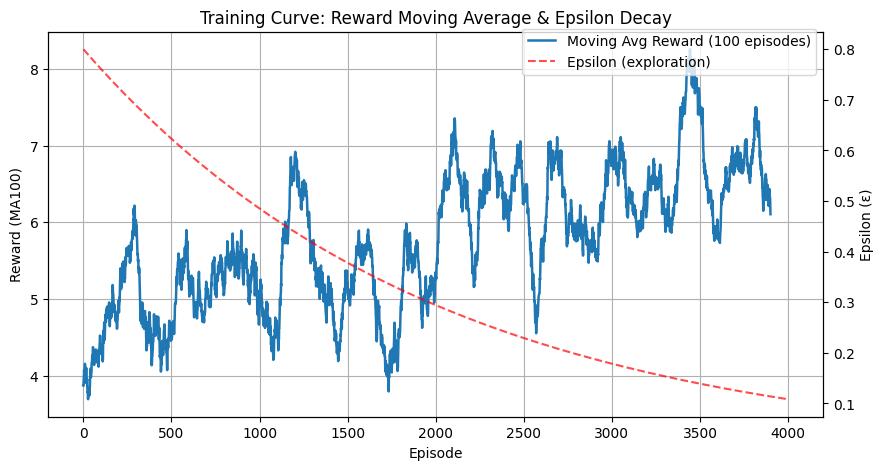

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# episode_rewards, eps_start, eps_decay, eps_end이 존재한다고 가정
# 만약 학습 중 eps값을 기록했다면 eps_values 리스트를 그대로 사용해도 됨.

# 1) Reward smoothing (moving average)
def moving_average(x, w=100):
    if len(x) < w:
        return np.convolve(x, np.ones(len(x))/len(x), mode='valid')
    return np.convolve(x, np.ones(w)/w, mode='valid')

er = np.array(episode_rewards)
er_ma = moving_average(er, w=100)

# 2) Episode별 epsilon 값 계산
eps_values = []
eps = EPS_START
for ep in range(len(episode_rewards)):
    eps_values.append(eps)
    eps = max(EPS_END, eps * EPS_DECAY)

eps_values = np.array(eps_values)

# 3) Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(10,5))

# Plot moving average reward
ax1.plot(er_ma, label='Moving Avg Reward (100 episodes)', linewidth=1.8)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Reward (MA100)")
ax1.grid(True)

# Second y-axis for epsilon
ax2 = ax1.twinx()
ax2.plot(eps_values, color='red', linestyle='--', label='Epsilon (exploration)', alpha=0.7)
ax2.set_ylabel("Epsilon (ε)")

# Titles & legends
plt.title("Training Curve: Reward Moving Average & Epsilon Decay")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))

plt.show()